In [1]:
from groq import Groq
from dotenv import load_dotenv
import os
import pandas as pd

In [2]:
load_dotenv()

client = Groq(
    api_key=os.getenv("GROQ_API_KEY")
)

print("Groq Connected")

Groq Connected


In [3]:
prompts = [
    "What is Artificial Intelligence?",
    "What is Machine Learning?",
    "Explain Deep Learning.",
    "What is Prompt Engineering?"
]

In [4]:
results = []

for prompt in prompts:

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    results.append({
        "Prompt": prompt,
        "Prompt Tokens": response.usage.prompt_tokens,
        "Completion Tokens": response.usage.completion_tokens,
        "Total Tokens": response.usage.total_tokens
    })

print("Tracking Complete")

Tracking Complete


In [5]:
df = pd.DataFrame(results)

df

,Prompt,Prompt Tokens,Completion Tokens,Total Tokens
0,What is Artificial Intelligence?,40,362,402
1,What is Machine Learning?,40,398,438
2,Explain Deep Learning.,40,655,695
3,What is Prompt Engineering?,40,443,483


In [6]:
print("Total Prompt Tokens:",
      df["Prompt Tokens"].sum())

print("Total Completion Tokens:",
      df["Completion Tokens"].sum())

print("Total Tokens:",
      df["Total Tokens"].sum())

Total Prompt Tokens: 160
Total Completion Tokens: 1858
Total Tokens: 2018


In [7]:
df.to_csv(
    "usage_logs.csv",
    index=False
)

print("CSV Saved")

CSV Saved


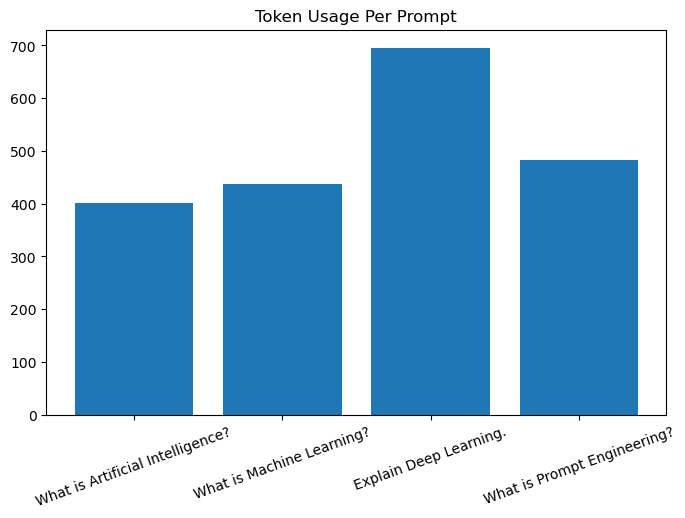

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df["Prompt"],
    df["Total Tokens"]
)

plt.title("Token Usage Per Prompt")
plt.xticks(rotation=20)

plt.show()

# Token Usage Analysis

## Objective
Measure token consumption for different prompts.

## Observation
Longer and more detailed prompts generally consume more tokens.

## Importance
Token tracking helps estimate API usage and cost when building AI applications.

## Conclusion
Monitoring token usage is important for optimizing performance and reducing operational costs.